<a href="https://colab.research.google.com/github/Kanchanajaddu/MLassignments/blob/main/MLassignmentq3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#given question:
Problem statement – 3 Customer Segmentation (Retail / E-commerce)

     An e-commerce company wants to segment its customers into groups to:

Personalize marketing campaigns

Recommend products

Improve customer retention

Since there are no labels, we use Clustering (e.g., K-Means).

CustomerID, Age, AnnualIncome, SpendingScore,VisitsPerMonth,AvgOrderValue
1,22,15000,39,4,200
2,25,18000,81,6,500
3,47,60000,6,2,150

4,52,65000,20,3,200
5,23,20000,77,5,450
6,45,70000,15,2,180
7,33,40000,50,4,300
8,35,42000,55,5,320
9,60,80000,10,1,100
10,28,30000,70,6,400

Feature Explanation

Age → Customer age

AnnualIncome → Income in ₹

SpendingScore → Engagement score (1–100)

VisitsPerMonth → Platform usage frequency

AvgOrderValue → Average purchase value

Interpretation

Why should you scale features before clustering?

What happens if features are on different scales?

Would you include CustomerID in clustering? Why/why not?

How do you decide the optimal number of clusters (K)?

Explain Elbow Method and Silhouette Score. Implement the Elbow Method (plot WCSS vs K from 1 to 10). Compute the Silhouette Score for different values of K.

Load the dataset and perform basic EDA (check nulls, summary stats).

Normalize/standardize the features using StandardScaler.

Apply K-Means clustering with k=3.

Print the cluster labels for each customer.

Find the centroids of each cluster.

Based on both methods, choose the optimal K.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

In [ ]:
#load the data
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age': [22, 25, 47, 52, 23, 45, 33, 35, 60, 28],
    'AnnualIncome': [15000, 18000, 60000, 65000, 20000, 70000, 40000, 42000, 80000, 30000],
    'SpendingScore': [39, 81, 6, 20, 77, 15, 50, 55, 10, 70],
    'VisitsPerMonth': [4, 6, 2, 3, 5, 2, 4, 5, 1, 6],
    'AvgOrderValue': [200, 500, 150, 200, 450, 180, 300, 320, 100, 400]
}

In [ ]:
data

{'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'Age': [22, 25, 47, 52, 23, 45, 33, 35, 60, 28],
 'AnnualIncome': [15000,
  18000,
  60000,
  65000,
  20000,
  70000,
  40000,
  42000,
  80000,
  30000],
 'SpendingScore': [39, 81, 6, 20, 77, 15, 50, 55, 10, 70],
 'VisitsPerMonth': [4, 6, 2, 3, 5, 2, 4, 5, 1, 6],
 'AvgOrderValue': [200, 500, 150, 200, 450, 180, 300, 320, 100, 400]}

In [ ]:
df=pd.DataFrame(data)

In [ ]:
df

,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
0,1,22,15000,39,4,200
1,2,25,18000,81,6,500
2,3,47,60000,6,2,150
3,4,52,65000,20,3,200
4,5,23,20000,77,5,450
5,6,45,70000,15,2,180
6,7,33,40000,50,4,300
7,8,35,42000,55,5,320
8,9,60,80000,10,1,100
9,10,28,30000,70,6,400


In [ ]:
df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
0,1,22,15000,39,4,200
1,2,25,18000,81,6,500
2,3,47,60000,6,2,150
3,4,52,65000,20,3,200
4,5,23,20000,77,5,450


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      10 non-null     int64
 1   Age             10 non-null     int64
 2   AnnualIncome    10 non-null     int64
 3   SpendingScore   10 non-null     int64
 4   VisitsPerMonth  10 non-null     int64
 5   AvgOrderValue   10 non-null     int64
dtypes: int64(6)
memory usage: 612.0 bytes


In [ ]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
count,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000
mean,5.50000,37.000000,44000.000000,42.300000,3.80000,280.000000
std,3.02765,13.266499,23518.314376,28.488009,1.75119,135.728487
min,1.00000,22.000000,15000.000000,6.000000,1.00000,100.000000
25%,3.25000,25.750000,22500.000000,16.250000,2.25000,185.000000
50%,5.50000,34.000000,41000.000000,44.500000,4.00000,250.000000
75%,7.75000,46.500000,63750.000000,66.250000,5.00000,380.000000
max,10.00000,60.000000,80000.000000,81.000000,6.00000,500.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
AnnualIncome,0
SpendingScore,0
VisitsPerMonth,0
AvgOrderValue,0


In [ ]:
#Prepare data for clustering
# Drop CustomerID as it's not a feature for clustering
X = df.drop('CustomerID', axis=1)

# Normalize/standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features (first 5 rows):")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

Scaled features (first 5 rows):


,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
0,-1.191828,-1.299782,-0.122104,0.120386,-0.621295
1,-0.953463,-1.165322,1.431949,1.324244,1.708561
2,0.794552,0.717121,-1.343146,-1.083473,-1.009604
3,1.191828,0.941222,-0.825128,-0.481543,-0.621295
4,-1.112373,-1.075682,1.283944,0.722315,1.320251


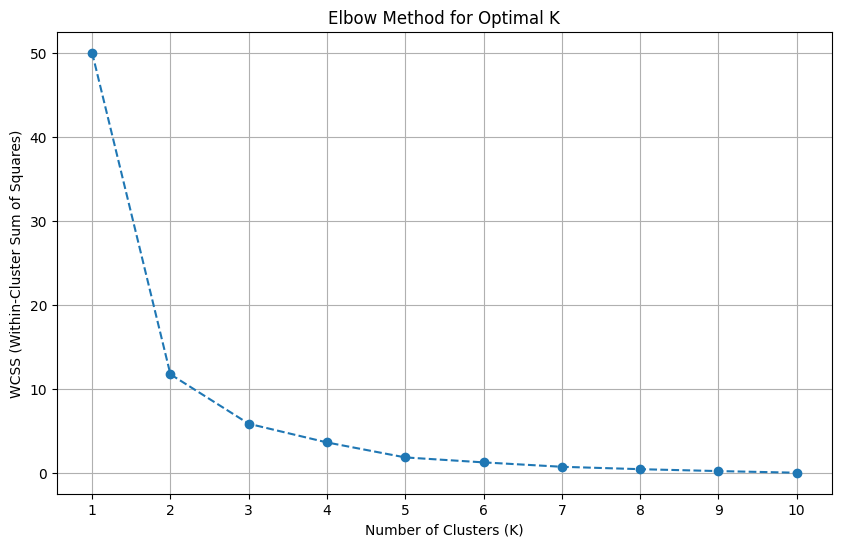

In [ ]:
#Determine the optimal number of clusters (K) using the Elbow Method and Silhouette Score
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot WCSS vs K
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


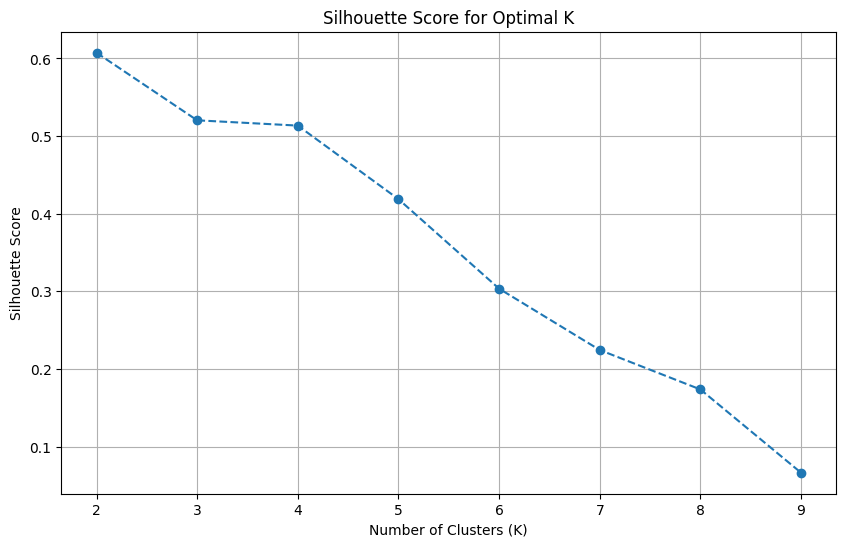

In [ ]:
# Compute the Silhouette Score for different values of K
silhouette_scores = []
for i in range(2, 10): # Changed range from 11 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Silhouette Score vs K
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, marker='o', linestyle='--') # Changed range from 11 to 10
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 10))
plt.grid(True)
plt.show()

In [ ]:
# Apply K-Means clustering with k=3 (as suggested or identified as optimal)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Print the cluster labels for each customer
df['Cluster'] = kmeans.labels_
print(f"\nCustomer data with assigned cluster labels for K={optimal_k}:")
display(df.sort_values(by='Cluster').head(10))

# Finding the centroids of each cluster
# Inverse transform the centroids to get them in the original feature scale for interpretability
centroids_scaled = kmeans.cluster_centers_
centroids_original_scale = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original_scale, columns=X.columns)

print(f"\nCentroids of each cluster (K={optimal_k}) in original scale:")
display(centroids_df)


Customer data with assigned cluster labels for K=3:


,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue,Cluster
3,4,52,65000,20,3,200,0
2,3,47,60000,6,2,150,0
5,6,45,70000,15,2,180,0
8,9,60,80000,10,1,100,0
4,5,23,20000,77,5,450,1
1,2,25,18000,81,6,500,1
9,10,28,30000,70,6,400,1
0,1,22,15000,39,4,200,2
7,8,35,42000,55,5,320,2
6,7,33,40000,50,4,300,2



Centroids of each cluster (K=3) in original scale:


,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
0,51.000000,68750.000000,12.75,2.000000,157.500000
1,25.333333,22666.666667,76.00,5.666667,450.000000
2,30.000000,32333.333333,48.00,4.333333,273.333333
